<a href="https://colab.research.google.com/github/Humak1/pneumonia-diagnosis-classifier/blob/main/2CWK50_ML_Huma_Kiyani_23633195.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Disclaimer for Viewers

This notebook has been prepared for sharing on GitHub. Please note the following:

*   **Cell Outputs Cleared:** All cell outputs have been cleared for a clean presentation on GitHub. You can reproduce all results by running the cells sequentially.
*   **Commented-out Code:** Some `print()` or `display()` statements within the code cells have been commented out to reduce clutter and manage the notebook's output during development. Uncomment them if you wish to see intermediate results.
*   **Data Handling:**
    *   `pneumonia_raw.csv` is loaded directly from a public URL, ensuring reproducibility without needing to include large datasets in the repository.
    *   `pneumonia_cleaned.csv` is a generated file. It is excluded from the GitHub repository using a `.gitignore` file to keep the repository lean and focused on code. This file will be generated automatically when you run the data cleaning cells.

Thank you for reviewing my work!

# 2CWK50

# Data loading

In [2]:
# Importing the packages we use
import pandas as pd
import numpy as np


# Loading all the observations
observations = pd.read_csv('https://helward.mmu.ac.uk/STAFF/J.Darby/ML/pneumonia_raw.csv')
# Removed print(observations.head()) to clear output. If you want to see the head again, uncomment this line or use display(observations.head()).

# Analysis

## Data Understanding

In this section, I explore the dataset to understand its structure, features, and target variable.



In [3]:
# print(observations.shape)
# print(observations.columns)
# print(observations.describe())

In [4]:
print("\nDUPLICATE ROWS:", observations.duplicated().sum())

duplicates = observations[observations.duplicated()]
# Removed print(duplicates) to clear output. If you want to see duplicates again, uncomment this line or use display(duplicates).


DUPLICATE ROWS: 1


In [5]:
# Removes exact duplicate rows
observations = observations.drop_duplicates()

# Treats invalid target label as missing
observations["Pneumonia"] = observations["Pneumonia"].replace("np", np.nan)

# Removes row with missing/invalid diagnosis
observations = observations.dropna(subset=["Pneumonia"])

# Replaces negative measurements
bad_cols = ["Max_Consolidation_Width", "Max_Consolidation_Height"]

observations[bad_cols] = observations[bad_cols].replace(-10000, np.nan)

# Removes rows containing corrupted measurements
observations = observations.dropna(
    subset=[
        "Max_Consolidation_Width",
        "Max_Consolidation_Height"
    ]
)

# Removes duplicate clinical records ignoring Patient_ID
feature_cols = observations.columns.drop("Patient_ID")

observations = observations.drop_duplicates(
    subset=feature_cols
)

# Separates features and target
X = observations.drop(
    ["Patient_ID", "Pneumonia"],
    axis=1
)

y = observations["Pneumonia"]

In [6]:
# Removed 'observations' as a standalone statement to clear full DataFrame output. If you want to display the full DataFrame again, use display(observations).

In [7]:
observations.to_csv("pneumonia_cleaned.csv", index=False)

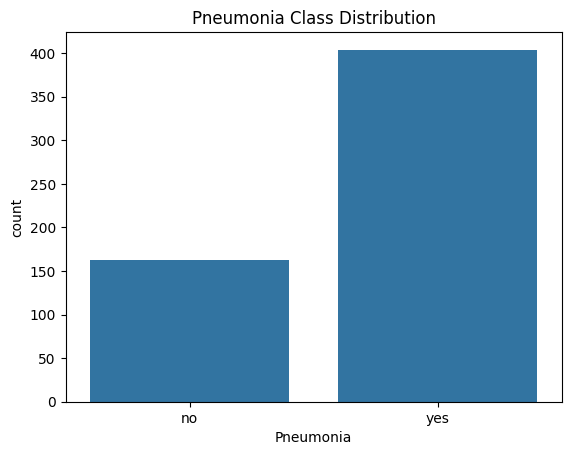

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Pneumonia Class Distribution")
plt.show()

>The dataset contains more pneumonia-positive patients than negative patients, meaning the data is slightly imbalanced and models may favour predicting pneumonia cases.

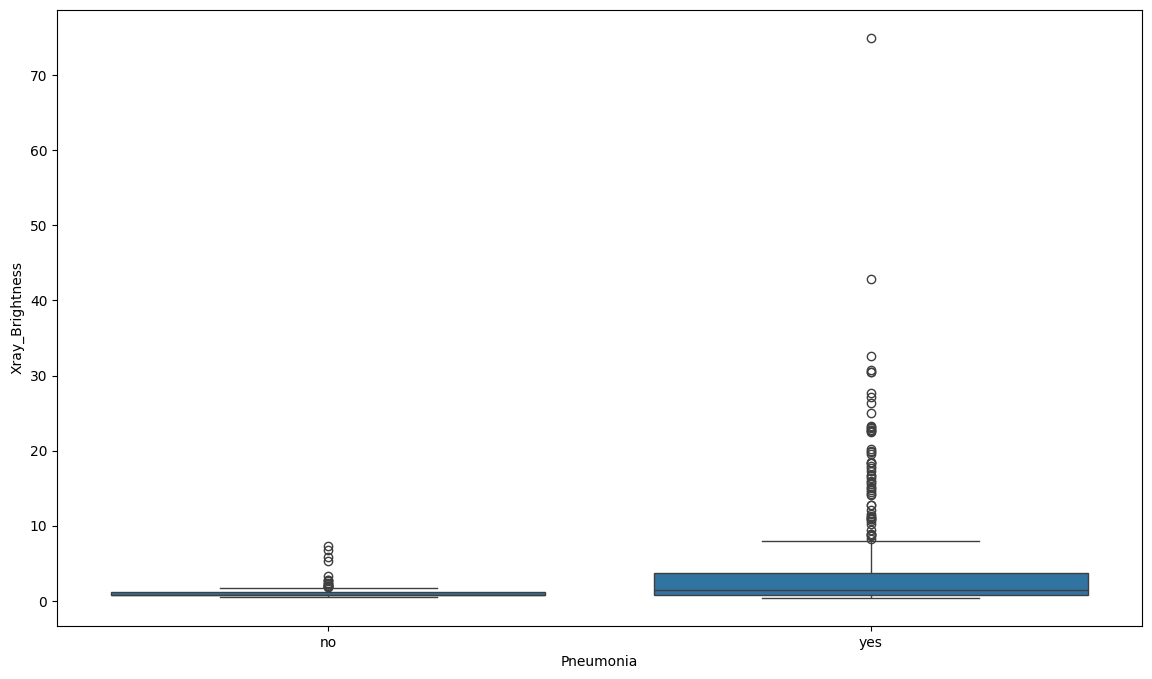

In [9]:
plt.figure(figsize=(14,8))

sns.boxplot(
    data=observations,
    x="Pneumonia",
    y="Xray_Brightness"
)

plt.show()

>Patients diagnosed with pneumonia generally show higher and more varied X-ray brightness values, suggesting brightness may help distinguish pneumonia cases.

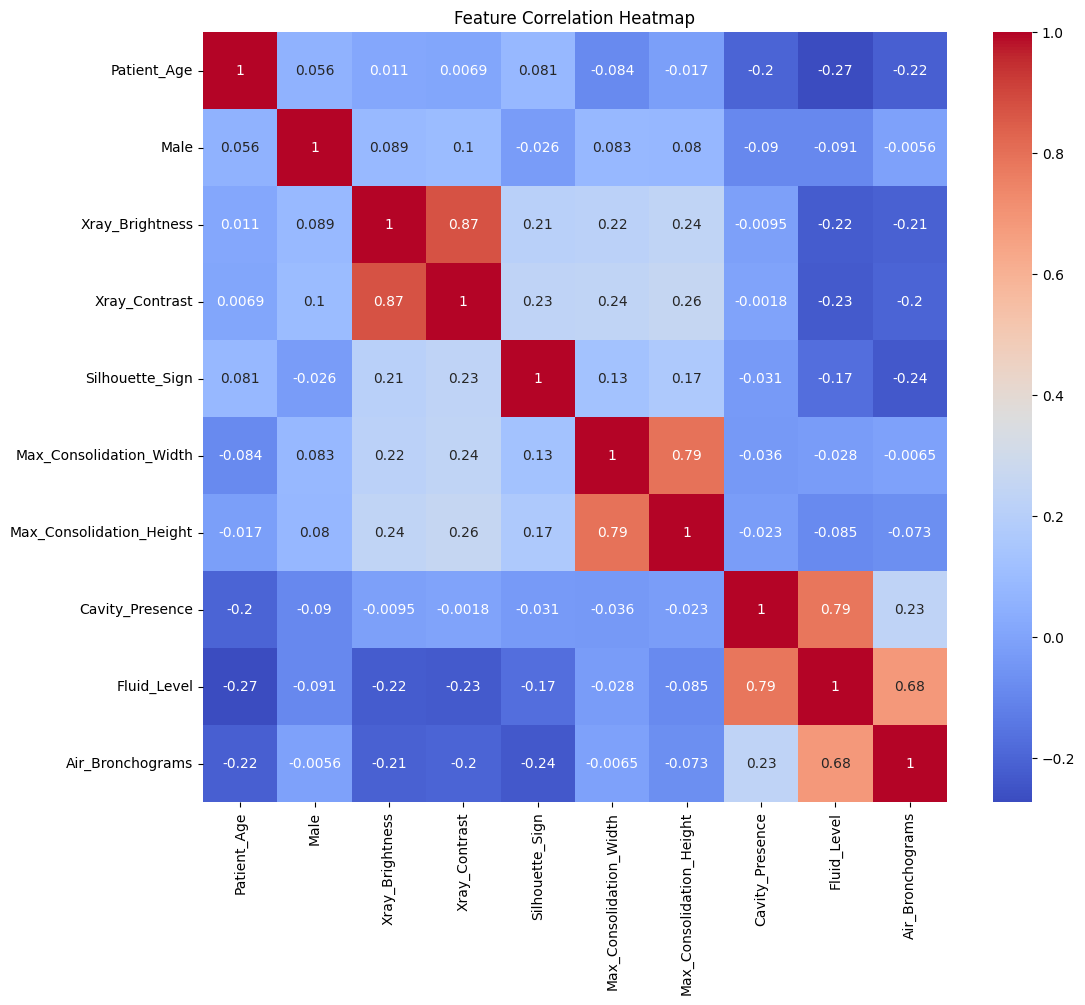

In [10]:
plt.figure(figsize=(12,10))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

>Several features are strongly related, especially Xray_Brightness and Xray_Contrast, indicating that certain X-ray measurements change together and may improve prediction accuracy.

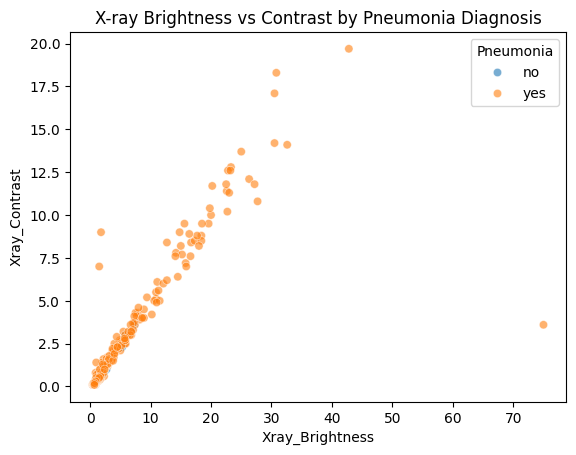

In [11]:
sns.scatterplot(
    data=observations,
    x="Xray_Brightness",
    y="Xray_Contrast",
    hue="Pneumonia",
    alpha=0.6
)

plt.title("X-ray Brightness vs Contrast by Pneumonia Diagnosis")
plt.show()

>Higher X-ray brightness is closely associated with higher contrast values in pneumonia cases, showing a clear pattern that machine learning models may learn from.

The initial analysis of the dataset showed several patterns that are important for understanding how pneumonia may be identified from chest X-ray measurements. The dataset contains more patients diagnosed with pneumonia than patients without it, which means the data is slightly unbalanced. The graphs also showed that patients with pneumonia often had higher X-ray brightness and contrast measurements compared to patients without pneumonia. In addition, pneumonia cases showed a wider range of values, including some extreme cases, which may represent patients with more serious infections.

The analysis also highlighted strong links between several of the X-ray measurements. For example, higher brightness values were usually associated with higher contrast values, suggesting that these features change together in patients with pneumonia. Other measurements linked to lung consolidation and fluid build-up also showed strong relationships. Overall, the data suggests that the measurements collected from chest X-rays contain useful information that could help machine learning models support faster pneumonia diagnosis. However, because the data includes some imbalance and unusual cases, the models will need to be tested carefully to ensure reliable and fair results before being used in a clinical setting.


## Data Preparation

To ensure fair comparison between models, the same shuffled 60/40 train/test split with random_state=99 was used throughout the main experiments.

Train/Test split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=99
)

The dataset was divided into training and testing sets using a 60/40 split. Stratified sampling was applied to preserve the class distribution across both sets. A fixed random seed (`random_state=99`) was used to ensure reproducibility.

Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

>Feature scaling was performed using StandardScaler, which standardises variables to have mean 0 and standard deviation 1. Scaling is important for distance and gradient-based models such as k-Nearest Neighbours, Support Vector Machines, and Logistic Regression.
To avoid data leakage, the scaler was fitted only on the training data before being applied to the test data.

# 1. Logistic Regression Model

Data Standardisation and Model Training

In [14]:
# Imports packages
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# Loads all the observations from file
observations = pd.read_csv('pneumonia_cleaned.csv')

# names the target feature
target_feature = 'Pneumonia'

# Shuffles observations
observations_shuffled = observations.sample(frac=1, random_state=99)

# Sets the fraction of observations we will use for testing
testing_fraction = 0.4
split_index = int(observations_shuffled.shape[0] * testing_fraction)

# Splits into testing observations and training observations ("horizontal split")
observations_test = observations_shuffled.iloc[:split_index]
observations_train = observations_shuffled.iloc[split_index:]

# Splits into testing examples and testing labels ("vertical split")
test_examples = observations_test.drop(columns=['Patient_ID', target_feature]).to_numpy()

test_labels = observations_test[target_feature].to_numpy()

# Splits into training examples and training labels ("vertical split")
train_examples = observations_train.drop(
    columns=['Patient_ID', target_feature]
).to_numpy()

train_labels = observations_train[target_feature].to_numpy()

# Creates a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()

# Computes means and standard deviations the training data
scaler.fit(train_examples)

# Divides individual feature values in the training data
# by their respective means and standard deviations
train_examples = scaler.transform(train_examples)

# Applies the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

#Logistic regression classification model object
model = SGDClassifier(random_state=99, loss='log_loss')

# Calls model's fitting/training algorithm
model.fit(train_examples, train_labels)

# Uses the trained model to generate predictions
predictions = model.predict(test_examples)

# Finds the total number of correct predictions
correct_predictions = sum(predictions == test_labels)

# Calculates the model's accuracy
accuracy = correct_predictions / len(test_labels)

# Displays the accuracy
print("Accuracy:",accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.6814159292035398 (or 68.1 %)


Model Evaluation

In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Display confusion matrix
print(confusion_matrix(test_labels, predictions))

# Display precision, recall and F1-score
print(classification_report(test_labels, predictions))

[[ 39  23]
 [ 49 115]]
              precision    recall  f1-score   support

          no       0.44      0.63      0.52        62
         yes       0.83      0.70      0.76       164

    accuracy                           0.68       226
   macro avg       0.64      0.67      0.64       226
weighted avg       0.73      0.68      0.70       226




> > The logistic regression model achieved an accuracy of 68%, performing better at identifying pneumonia cases than non-pneumonia cases, with strong precision (0.83) and recall (0.70) for pneumonia patients, although further improvement would be required before clinical deployment.

Feature Importance

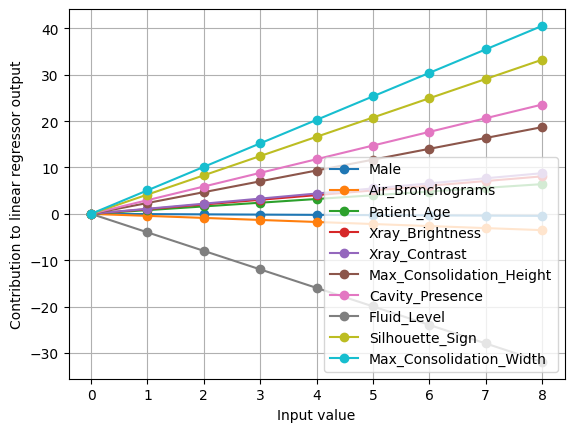

And the final constant offset is: 4.272


In [16]:
import matplotlib.pyplot as plt

# Grabs a record of the predictive features
predictive_features = observations.drop(
    columns=['Patient_ID', target_feature]
).columns.to_numpy()

# Gets all the model parameters
coef_ = model.coef_[0]

# Keep only the top 10 strongest
idx = np.argsort(np.abs(coef_))[-10:]
coef_ = coef_[idx]
predictive_features = predictive_features[idx]

# Shows the strongest learned coefficients graphically
plt.figure()

for index, c in enumerate(coef_):
    plt.plot(
        range(0, 9),
        range(0, 9) * c,
        marker='o',
        linestyle='-',
        label=predictive_features[index]
    )

plt.xlabel('Input value')
plt.ylabel('Contribution to linear regressor output')
plt.grid(True)
plt.legend()
plt.show()

# And the constant offset
print(f"And the final constant offset is: {model.intercept_[0]:.3f}")

>It shows the ten most influential features learned by the logistic regression model when predicting pneumonia. Features with steep positive slopes, such as Max_Consolidation_Width, Silhouette_Sign, Cavity_Presence, and Max_Consolidation_Height, had the strongest positive influence on pneumonia predictions, meaning higher values increased the likelihood of the model predicting pneumonia. Features with negative slopes, such as Fluid_Level and Air_Bronchograms, reduced the likelihood of a pneumonia prediction as their values increased. Flatter lines, including Patient_Age and Xray_Brightness, had little influence on the model’s decisions.



Probability Outputs

In [17]:
import numpy as np

def logistic(x):
  return 1 / (1 + np.exp(-x))

# Adds a column of ones to the matrix of testing examples to account for the intercept
test_examples_with_intercept = np.c_[test_examples, np.ones((test_examples.shape[0], 1))]

# Get the model's parameters (coefficients and intercept) into a matrix with a single column ('column vector')
params = np.atleast_2d(np.append(model.coef_, model.intercept_)).T

# Calculates the linear regression predictions using a single matrix multiply
predictions = test_examples_with_intercept @ params

# Computes the logistic function responses and prints frist five
predictions = logistic(predictions)
print(predictions[ :5])

# Prints first 5 of the probabilities produced by the model
print(model.predict_proba(test_examples[ :5]))

[[0.74906065]
 [0.00583906]
 [0.42103702]
 [0.99999974]
 [0.37739267]]
[[2.50939349e-01 7.49060651e-01]
 [9.94160941e-01 5.83905947e-03]
 [5.78962981e-01 4.21037019e-01]
 [2.63019191e-07 9.99999737e-01]
 [6.22607326e-01 3.77392674e-01]]


>The model produced probability scores for each patient, showing how confident the model was in predicting pneumonia. Higher probabilities indicated greater confidence that a patient had pneumonia, while lower probabilities suggested the patient was unlikely to have pneumonia.

>This is useful because it allows predictions to be interpreted with different levels of certainty rather than only giving a simple yes/no result.

In [18]:
from sklearn.preprocessing import PolynomialFeatures

print(f"before PF we have: {train_examples.shape[1]} features")

pf = PolynomialFeatures(degree=2, include_bias=False)

train_examples_pf = pf.fit_transform(train_examples)
test_examples_pf = pf.transform(test_examples)

print(f"after PF we have: {train_examples_pf.shape[1]} features")

# Creates a logistic regression classification model object
model_pf = SGDClassifier(random_state=99, loss='log_loss')

# Fits model to the training data
model_pf.fit(train_examples_pf, train_labels)

# Generates predictions
predictions_pf = model_pf.predict(test_examples_pf)

# Finds the total number of correct predictions
correct_predictions_pf = sum(predictions_pf == test_labels)

# Calculates the model's accuracy
accuracy_pf = correct_predictions_pf / len(test_labels)

print("Accuracy:", accuracy_pf, "(or", round(accuracy_pf * 100, 1), "%)")

before PF we have: 10 features
after PF we have: 65 features
Accuracy: 0.672566371681416 (or 67.3 %)


In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(confusion_matrix(test_labels, predictions_pf))

print(classification_report(test_labels, predictions_pf))

[[ 17  45]
 [ 29 135]]
              precision    recall  f1-score   support

          no       0.37      0.27      0.31        62
         yes       0.75      0.82      0.78       164

    accuracy                           0.67       226
   macro avg       0.56      0.55      0.55       226
weighted avg       0.65      0.67      0.66       226



>The polynomial features increased the number of predictive features from 10 to 65 by creating additional interactions between measurements. However, despite the increased complexity, classification performance decreased overall. The model struggled to correctly identify non-pneumonia patients, producing a large number of false positives. This suggests that the expanded feature space may have introduced overfitting or added noise within the dataset.

### Cross-Validation Evaluation

In [20]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score

# Creates a pipeline that first scales the data and then applies the classifier
# This correctly handles scaling within each cross-validation fold to prevent data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_model', SGDClassifier(random_state=99, loss='log_loss'))
])

# Defines a custom F1 scorer to specify the positive label
f1_scorer = make_scorer(f1_score, pos_label='yes')

# Performs cross-validation with the pipeline and use the custom F1 scorer
scores = cross_val_score(pipeline, X, y, cv=5, scoring=f1_scorer, error_score='raise')

print("F1 scores:", scores)
print("Mean F1:", scores.mean())
print("Standard deviation:", scores.std())

F1 scores: [0.79268293 0.84042553 0.80851064 0.74324324 0.81818182]
Mean F1: 0.8006088316934191
Standard deviation: 0.0325891046959346


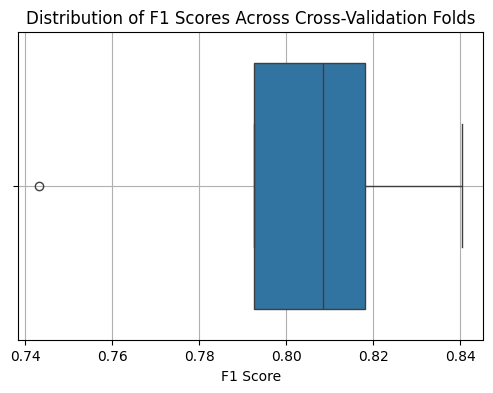

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(x=scores)
plt.title('Distribution of F1 Scores Across Cross-Validation Folds')
plt.xlabel('F1 Score')
plt.grid(True)
plt.show()

>Results show consistent model performance across different subsets of the data, with F1 scores ranging from 0.74 to 0.84 and a mean F1 score of 0.80 (±0.03). This suggests that the logistic regression model was stable and generalised well, meaning it is likely to perform reliably on unseen patient data rather than only performing well on the training set.


# 2. Support Vector Machine

### SVM Model

In [22]:
# Import the packages we use
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Creates an SVM classification model object
model_svm = SVC(random_state=99)

# Fits the model to our training data
model_svm.fit(train_examples, train_labels)

# Uses the trained model to generate predictions
predictions_svm = model_svm.predict(test_examples)

# Finds the total number of correct predictions
correct_predictions_svm = sum(predictions_svm == test_labels)

# Calculates the model's accuracy
accuracy_svm = correct_predictions_svm / len(test_labels)

# Displays the accuracy
print("Accuracy:", accuracy_svm, "(or", round(accuracy_svm * 100, 1), "%)")

# Displays the confusion matrix
print(confusion_matrix(test_labels, predictions_svm))

# Displays the classification report
print(classification_report(test_labels, predictions_svm))

Accuracy: 0.7168141592920354 (or 71.7 %)
[[  5  57]
 [  7 157]]
              precision    recall  f1-score   support

          no       0.42      0.08      0.14        62
         yes       0.73      0.96      0.83       164

    accuracy                           0.72       226
   macro avg       0.58      0.52      0.48       226
weighted avg       0.65      0.72      0.64       226



>The SVM model achieved an accuracy of 71.7% and performed very well at identifying pneumonia cases with a recall of 0.96, correctly classifying 157 pneumonia patients, although it struggled to identify non-pneumonia cases, correctly classifying only 5 healthy patients.


### Cross-Validation Evaluation for SVM

In [23]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score

# Creates a pipeline that first scales the data and then applies the SVM classifier
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_model', SVC(random_state=99))
])

# Defines a custom F1 scorer to specify the positive label
f1_scorer = make_scorer(f1_score, pos_label='yes')

# Performs cross-validation with the pipeline and use the custom F1 scorer
svm_scores = cross_val_score(pipeline_svm, X, y, cv=5, scoring=f1_scorer, error_score='raise')

print("SVM F1 scores:", svm_scores)
print("Mean SVM F1:", svm_scores.mean())
print("Standard deviation of SVM F1:", svm_scores.std())

SVM F1 scores: [0.78494624 0.83076923 0.82901554 0.78021978 0.78453039]
Mean SVM F1: 0.8018962356659867
Standard deviation of SVM F1: 0.022925316278462282


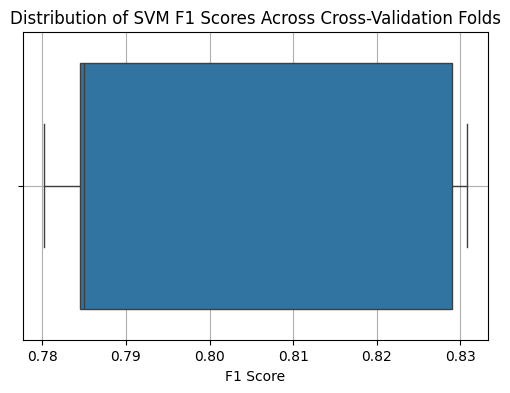

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates box plot of SVM cross-validation F1 scores
plt.figure(figsize=(6, 4))
sns.boxplot(x=svm_scores)

# Adds title and labels
plt.title('Distribution of SVM F1 Scores Across Cross-Validation Folds')
plt.xlabel('F1 Score')

# Displays grid and plot
plt.grid(True)
plt.show()

>The model shows consistent performance across different subsets of the data, with F1 scores ranging from 0.78 to 0.83 and a mean F1 score of 0.80 (±0.02). The low standard deviation indicates that the model performed reliably across folds, suggesting good stability and generalisation to unseen patient data.

### Hyperparameter Tuning for SVM using Grid Search

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_model', SVC(random_state=99))
])

# Defines the parameter grid to search
param_grid = {
    'svm_model__C': [0.1, 1, 10, 100],
    'svm_model__kernel': ['linear', 'rbf', 'poly']
}

# Defines the custom F1 scorer (if not already defined in the current scope)
f1_scorer = make_scorer(f1_score, pos_label='yes')

# Creates GridSearchCV object
grid_search = GridSearchCV(
    pipeline_svm,
    param_grid,
    cv=5,
    scoring=f1_scorer,
    error_score='raise',
    n_jobs=-1,
    verbose=1
)

# Fits the grid search to the data
grid_search.fit(X_train, y_train)

# Gets the best SVM model from the grid search
best_svm_model = grid_search.best_estimator_

predictions_best_svm = best_svm_model.predict(X_test)

# Prints the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found:  {'svm_model__C': 0.1, 'svm_model__kernel': 'linear'}
Best F1 score found:  0.8315944591806661


>The grid search found that the best SVM model used a linear kernel with C=0.1, achieving a strong F1-score of 0.83.

### Confusion Matrix for Best SVM Model

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


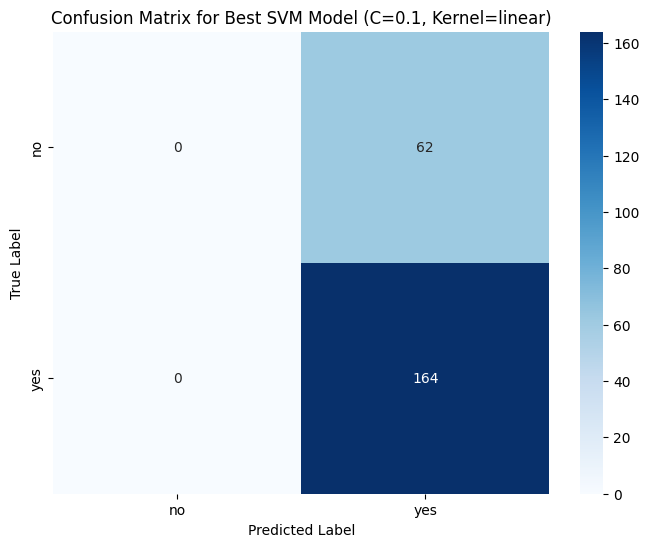

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gets the best pipeline from the grid search
best_svm_model = grid_search.best_estimator_

# Makes predictions on the scaled test data using the best model
predictions_best_svm = best_svm_model.predict(test_examples)

# Generates the confusion matrix
cm_best_svm = confusion_matrix(test_labels, predictions_best_svm)

# Plots the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_best_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_svm_model.classes_,
    yticklabels=best_svm_model.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best SVM Model (C=0.1, Kernel=linear)')
plt.show()

>The confusion matrix shows that the optimised SVM model classified all patients as pneumonia-positive, successfully identifying all 164 pneumonia cases but failing to correctly identify any non-pneumonia patients, indicating high sensitivity but poor specificity.

In [27]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy for the best SVM model on the test set
accuracy_best_svm = accuracy_score(test_labels, predictions_best_svm)

print(f"Accuracy of Best SVM Model: {accuracy_best_svm:.3f} (or {accuracy_best_svm * 100:.1f}%)\n")

# Print the raw confusion matrix
print("Raw Confusion Matrix:")
print(cm_best_svm)

# Print the classification report
print("\nClassification Report:")
print(classification_report(test_labels, predictions_best_svm))

Accuracy of Best SVM Model: 0.726 (or 72.6%)

Raw Confusion Matrix:
[[  0  62]
 [  0 164]]

Classification Report:
              precision    recall  f1-score   support

          no       0.00      0.00      0.00        62
         yes       0.73      1.00      0.84       164

    accuracy                           0.73       226
   macro avg       0.36      0.50      0.42       226
weighted avg       0.53      0.73      0.61       226



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Investigating SVM Kernels

In [28]:
# Empty lists to store results
kernel_names = []
accuracies = []

# Trying different SVM kernels
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:

    # SVM classification model
    model_svm = SVC(
        kernel=kernel,
        random_state=99
    )

    # Trains the model
    model_svm.fit(train_examples, train_labels)

    # Predictions
    predictions_svm = model_svm.predict(test_examples)

    # Calculates accuracy
    correct_predictions_svm = sum(
        predictions_svm == test_labels
    )

    accuracy_svm = (
        correct_predictions_svm / len(test_labels)
    )

    # Stores results
    kernel_names.append(kernel)
    accuracies.append(accuracy_svm)

    # Displays accuracy
    print(
        "Kernel:",
        kernel,
        "Accuracy:",
        accuracy_svm,
        "(or",
        round(accuracy_svm * 100, 1),
        "%)"
    )

Kernel: linear Accuracy: 0.7256637168141593 (or 72.6 %)
Kernel: rbf Accuracy: 0.7168141592920354 (or 71.7 %)
Kernel: poly Accuracy: 0.7035398230088495 (or 70.4 %)


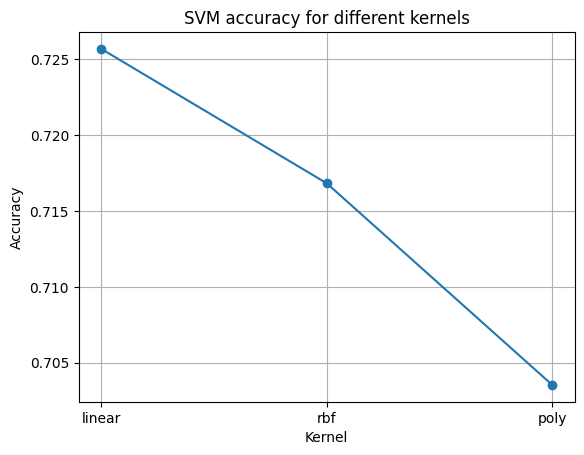

In [29]:
import matplotlib.pyplot as plt

# Shows the relationship between kernel choice and accuracy
plt.figure()

plt.plot(
    kernel_names,
    accuracies,
    marker='o'
)

plt.xlabel('Kernel')
plt.ylabel('Accuracy')

plt.title('SVM accuracy for different kernels')

plt.grid(True)
plt.show()

>The linear kernel achieved the highest SVM accuracy (72.6%), outperforming the rbf and polynomial kernels, suggesting that a simpler linear decision boundary was most suitable for this dataset.

### Investigating SVM Regularisation

In [30]:
# Creates empty lists to store results
c_values = []
accuracies = []

# Tries different values of C
c_test_values = [0.1, 1, 10]

for c in c_test_values:

    # Creates an SVM classification model
    model_svm = SVC(
        C=c,
        kernel='rbf',
        random_state=99
    )

    # Trains the model
    model_svm.fit(train_examples, train_labels)

    # Generates predictions
    predictions_svm = model_svm.predict(test_examples)

    # Calculates accuracy
    correct_predictions_svm = sum(
        predictions_svm == test_labels
    )

    accuracy_svm = (
        correct_predictions_svm / len(test_labels)
    )

    # Stores the results
    c_values.append(c)
    accuracies.append(accuracy_svm)

    # Displays the accuracy
    print(
        "C:",
        c,
        "Accuracy:",
        accuracy_svm,
        "(or",
        round(accuracy_svm * 100, 1),
        "%)"
    )

C: 0.1 Accuracy: 0.7256637168141593 (or 72.6 %)
C: 1 Accuracy: 0.7168141592920354 (or 71.7 %)
C: 10 Accuracy: 0.6504424778761062 (or 65.0 %)


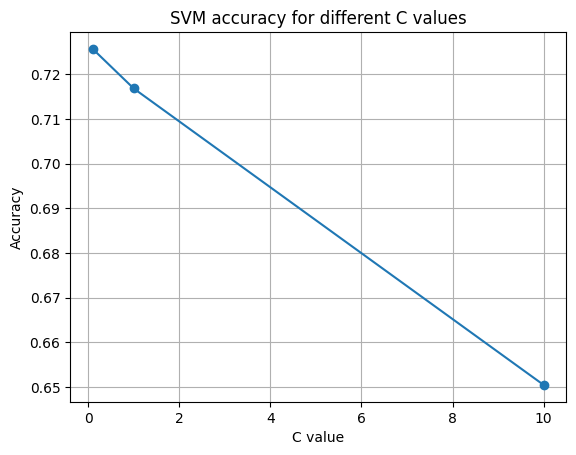

In [31]:
# Shows the relationship between C and accuracy
plt.figure()

plt.plot(
    c_values,
    accuracies,
    marker='o'
)

plt.xlabel('C value')
plt.ylabel('Accuracy')

plt.title('SVM accuracy for different C values')

plt.grid(True)
plt.show()

>The lower C values produced the best SVM performance, with C=0.1 achieving the highest accuracy (72.6%), suggesting that stronger regularisation improved the model’s ability to generalise to unseen data.

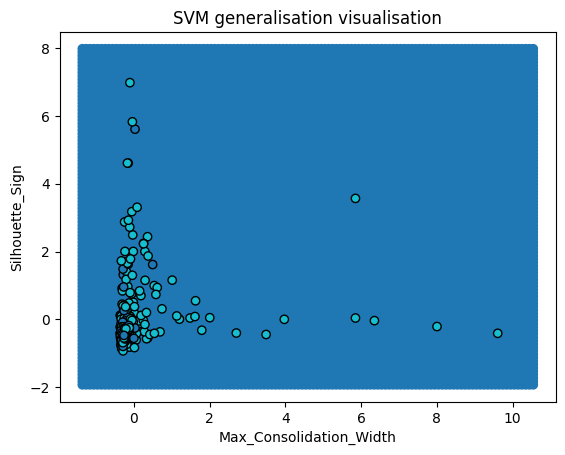

In [32]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Selects two predictive features for visualisation
feature_1 = 'Max_Consolidation_Width'
feature_2 = 'Silhouette_Sign'

# Creates a smaller dataset using only two features
observations_2d = observations[[feature_1, feature_2, target_feature]]

# Shuffles all the observations
observations_shuffled_2d = observations_2d.sample(frac=1, random_state=99)

# Split into testing observations and training observations ("horizontal split")
observations_test_2d = observations_shuffled_2d.iloc[:split_index]
observations_train_2d = observations_shuffled_2d.iloc[split_index:]

# Split into testing examples and testing labels ("vertical split")
test_examples_2d = observations_test_2d.drop(columns=target_feature).to_numpy()
test_labels_2d = observations_test_2d[target_feature].to_numpy()

# Split into training examples and training labels ("vertical split")
train_examples_2d = observations_train_2d.drop(columns=target_feature).to_numpy()
train_labels_2d = observations_train_2d[target_feature].to_numpy()

# Create a new StandardScaler object, ready to do z-score standardisation
scaler_2d = StandardScaler()

# Compute means and standard deviations for each feature in the training data
scaler_2d.fit(train_examples_2d)

# Divide individual feature values in the training data by their respective means and standard deviations
train_examples_2d = scaler_2d.transform(train_examples_2d)

# Apply the same transformation to the testing examples
test_examples_2d = scaler_2d.transform(test_examples_2d)

# Create an SVM classification model object for 2D visualization
model_svm_2d = SVC(random_state=99)

# Fit the model to our 2D training data
model_svm_2d.fit(train_examples_2d, train_labels_2d)

# Grids of testing examples to use in visualisation
x_min = train_examples_2d[:, 0].min() - 1
x_max = train_examples_2d[:, 0].max() + 1
y_min = train_examples_2d[:, 1].min() - 1
y_max = train_examples_2d[:, 1].max() + 1

jump = 0.1

grid_x, grid_y = np.meshgrid(
    np.arange(x_min, x_max, jump),
    np.arange(y_min, y_max, jump)
)

grid_examples = np.c_[grid_x.ravel(), grid_y.ravel()]

# Predictions for examples in the grid
grid_predictions = model_svm_2d.predict(grid_examples)

# Visualises generalisation
plt.figure()

unique_labels, grid_labels_int = np.unique(grid_predictions, return_inverse=True)

plt.scatter(
    grid_examples[:, 0],
    grid_examples[:, 1],
    c=grid_labels_int,
    cmap='tab10'
)

unique_labels, train_labels_int = np.unique(train_labels_2d, return_inverse=True)

plt.scatter(
    train_examples_2d[:, 0],
    train_examples_2d[:, 1],
    c=train_labels_int,
    edgecolors='black',
    cmap='tab10'
)

plt.xlabel('Max_Consolidation_Width')
plt.ylabel('Silhouette_Sign')
plt.title('SVM generalisation visualisation')

plt.show()

# 3. K-Nearest Neighbours

Data Standardisation

In [33]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

observations = pd.read_csv('pneumonia_cleaned.csv')

target_feature = 'Pneumonia'

# Shuffles observations
observations_shuffled = observations.sample(frac=1, random_state=99)

# Sets the fraction of observations for testing
testing_fraction = 0.4
split_index = int(observations_shuffled.shape[0] * testing_fraction)

# Splits into testing observations and training observations ("horizontal split")
observations_test = observations_shuffled.iloc[:split_index]
observations_train = observations_shuffled.iloc[split_index:]

# Splits into testing examples and testing labels ("vertical split")
test_examples = observations_test.drop(columns=['Patient_ID', target_feature]).to_numpy()
test_labels = observations_test[target_feature].to_numpy()

# Splits into training examples and training labels ("vertical split")
train_examples = observations_train.drop(columns=['Patient_ID', target_feature]).to_numpy()
train_labels = observations_train[target_feature].to_numpy()

# Creates a new StandardScaler object
scaler = StandardScaler()

# Mean and standard deviations for features in the training data
scaler.fit(train_examples)

# Divides individual feature values in training data by their means and standard deviations
train_examples = scaler.transform(train_examples)

# Applies the same to the testing examples
test_examples = scaler.transform(test_examples)

>The k-nearest neighbours model predicted pneumonia by comparing each patient with the most similar patients in the training data. The model used the 5 nearest neighbours to determine whether a patient was more likely to have pneumonia or not.

Initial kNN Model

In [34]:
# Creates a k-NN classification model
model = KNeighborsClassifier(n_neighbors=5)

# Calls the model's fitting/training algorithm
model.fit(train_examples, train_labels)

# Uses the trained model to generate predictions based on testing examples
predictions = model.predict(test_examples)

# Finds the total number of model predictions that matched with their testing labels
correct_predictions = sum(predictions == test_labels)

# Calculates model's accuracy: the fraction of predictions that were correct
accuracy = correct_predictions / len(test_labels)

# Displays the accuracy as a single quantitative measure of overall performance
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

# Displays the confusion matrix
print(confusion_matrix(test_labels, predictions))

# Displays the classification report
print(classification_report(test_labels, predictions))

Accuracy: 0.6858407079646017 (or 68.6 %)
[[ 23  39]
 [ 32 132]]
              precision    recall  f1-score   support

          no       0.42      0.37      0.39        62
         yes       0.77      0.80      0.79       164

    accuracy                           0.69       226
   macro avg       0.60      0.59      0.59       226
weighted avg       0.67      0.69      0.68       226



> An accuracy of 68.6%, with stronger performance in identifying pneumonia cases than non-pneumonia cases. The model achieved a recall of 0.80 for pneumonia cases, indicating that most pneumonia patients were correctly identified, although performance for healthy patients was weaker, with a recall of 0.37.


Investigating k Values

In [35]:
# Creates empty lists to store results
k_values = []
accuracies = []

# Tries five values of k
k_test_values = [1, 3, 10, 15, 19]

for k in k_test_values:

  # Creates a k-NN classification model
  model = KNeighborsClassifier(n_neighbors=k)

  # Train sthe model
  model.fit(train_examples, train_labels)

  # Generates predictions
  predictions = model.predict(test_examples)

  # Calculates accuracy
  correct_predictions = sum(predictions == test_labels)
  accuracy = correct_predictions / len(test_labels)

  # Stores the results
  k_values.append(k)
  accuracies.append(accuracy)

  # Displays the accuracy
  print("k:", k, "Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

k: 1 Accuracy: 0.6637168141592921 (or 66.4 %)
k: 3 Accuracy: 0.6592920353982301 (or 65.9 %)
k: 10 Accuracy: 0.6371681415929203 (or 63.7 %)
k: 15 Accuracy: 0.6902654867256637 (or 69.0 %)
k: 19 Accuracy: 0.6814159292035398 (or 68.1 %)


>Different values of k were investigated to assess how neighbourhood size affected classification performance. The lowest accuracy occurred at k=1, suggesting that relying on only the nearest neighbour caused the model to overfit local noise within the training data. Performance improved as k increased, with the best result achieved at k=15. However, performance decreased slightly again at k=19, indicating that large neighbourhoods may oversimplify the decision boundary and reduce sensitivity to important local patterns.

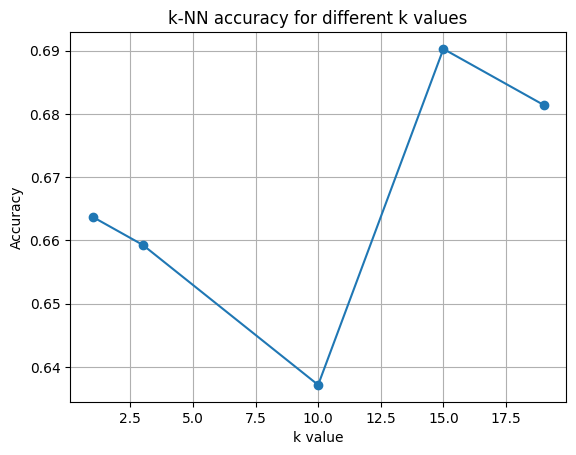

In [36]:
# Shows the relationship between k and accuracy graphically
plt.figure()

plt.plot(k_values, accuracies, marker='o')

plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('k-NN accuracy for different k values')

plt.grid(True)
plt.show()


Best Knn model

In [37]:
# Creates a k-NN classification model using the best value of k
model = KNeighborsClassifier(n_neighbors=15)

# Call the model's fitting/training algorithm, passing in the training examples and training labels
model.fit(train_examples, train_labels)

# Uses the trained model to generate predictions based on the testing examples
predictions = model.predict(test_examples)

# Finds the total number of model predictions that matched with their testing labels
correct_predictions = sum(predictions == test_labels)

# Calculates the model's accuracy: the fraction of predictions that were correct
accuracy = correct_predictions / len(test_labels)

# Displays the accuracy as a single quantitative measure of overall performance
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

# Displays the confusion matrix
print(confusion_matrix(test_labels, predictions))

# Displays the classification report
print(classification_report(test_labels, predictions))

Accuracy: 0.6902654867256637 (or 69.0 %)
[[ 19  43]
 [ 27 137]]
              precision    recall  f1-score   support

          no       0.41      0.31      0.35        62
         yes       0.76      0.84      0.80       164

    accuracy                           0.69       226
   macro avg       0.59      0.57      0.57       226
weighted avg       0.67      0.69      0.67       226



> The k-NN model achieved an accuracy of 69.0% using *k = 15* and showed strong recall for pneumonia-positive patients (0.84), although performance for non-pneumonia patients remained weaker, suggesting further refinement and additional data would be required before clinical use.


Feature space visualisation

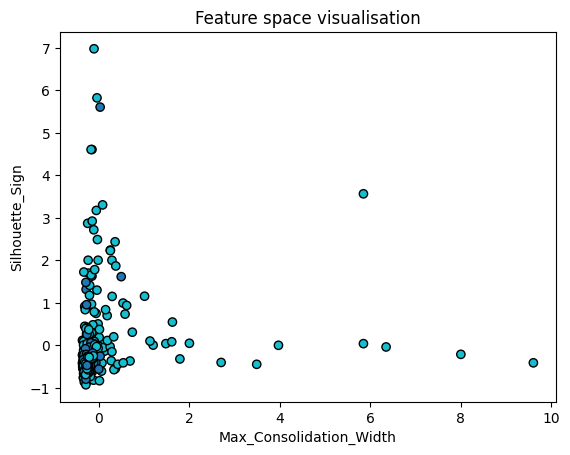

In [38]:
# Selects two predictive features for visualisation
feature_1 = 'Max_Consolidation_Width'
feature_2 = 'Silhouette_Sign'

# Create a smaller dataset using only two features
observations_2d = observations[[feature_1, feature_2, target_feature]]

# Shuffle all the observations
observations_shuffled_2d = observations_2d.sample(frac=1, random_state=99)

# Split into testing observations and training observations ("horizontal split")
observations_test_2d = observations_shuffled_2d.iloc[:split_index]
observations_train_2d = observations_shuffled_2d.iloc[split_index:]

# Split into testing examples and testing labels ("vertical split")
test_examples_2d = observations_test_2d.drop(columns=target_feature).to_numpy()
test_labels_2d = observations_test_2d[target_feature].to_numpy()

# Split into training examples and training labels ("vertical split")
train_examples_2d = observations_train_2d.drop(columns=target_feature).to_numpy()
train_labels_2d = observations_train_2d[target_feature].to_numpy()

# Create a new StandardScaler object, ready to do z-score standardisation
scaler_2d = StandardScaler()

# Compute means and standard deviations for each feature in the training data
scaler_2d.fit(train_examples_2d)

# Divide individual feature values in the training data by their respective means and standard deviations
train_examples_2d = scaler_2d.transform(train_examples_2d)

# Apply the same transformation to the testing examples
test_examples_2d = scaler_2d.transform(test_examples_2d)

# Visualise training data in feature space
plt.figure()

# Matplotlib wants integers for the colour codes in our scatter plot: convert our string-based labels over
unique_labels, train_labels_int = np.unique(train_labels_2d, return_inverse=True)

# Plot the training data
plt.scatter(train_examples_2d[:, 0], train_examples_2d[:, 1], c=train_labels_int, edgecolors='black', cmap='tab10')

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title('Feature space visualisation')
plt.show()

>Most data points are clustered closely together around lower values of *Max_Consolidation_Width*, while a smaller number of outliers are spread further across the feature space. This suggests that the dataset may contain overlapping patterns between classes, which could make it more difficult for machine learning models such as k-NN to clearly separate pneumonia and non-pneumonia cases.


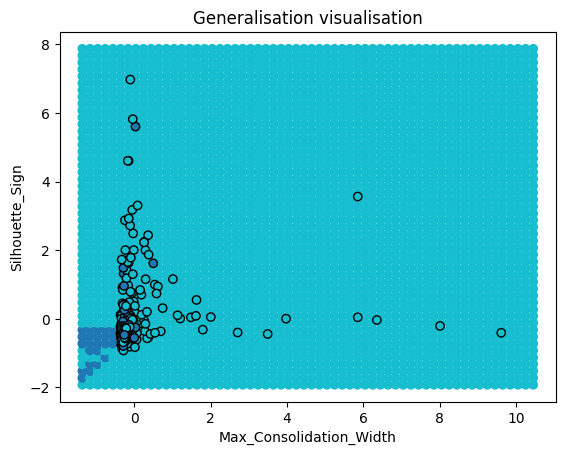

In [39]:
# Creates a k-NN classification model
model = KNeighborsClassifier(n_neighbors=15)

# Call the model's fitting/training algorithm, passing in our training examples and training labels
model.fit(train_examples_2d, train_labels_2d)

# Prepare our own grid of testing examples to use in visualization
x_min = train_examples_2d[:, 0].min() - 1
x_max = train_examples_2d[:, 0].max() + 1
y_min = train_examples_2d[:, 1].min() - 1
y_max = train_examples_2d[:, 1].max() + 1

# Adjust this to get more/less definition in the grid
jump = 0.2

# Get help from numpy's meshgrid() function to be fast
grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max, jump), np.arange(y_min, y_max, jump))

# Turn the results back into a deep table with only 2 columns
grid_examples = np.c_[grid_x.ravel(), grid_y.ravel()]

# Make predictions for each of the examples in the grid
grid_predictions = model.predict(grid_examples)

# Visualise the final generalisation
plt.figure()

# Matplotlib wants integers for the colour codes in our scatter plot: convert our string-based labels over
unique_labels, grid_labels_int = np.unique(grid_predictions, return_inverse=True)

# Plot the generalisation
plt.scatter(grid_examples[:, 0], grid_examples[:, 1], c=grid_labels_int, cmap='tab10')

# Plot the training data
plt.scatter(train_examples_2d[:, 0], train_examples_2d[:, 1], c=train_labels_int, edgecolors='black', cmap='tab10')

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title('Generalisation visualisation')
plt.show()



> The visualisation suggests that the k-NN model prioritised identifying pneumonia cases across most of the feature space, which may help support faster clinical decision-making for NHS staff, although the limited recognition of non-pneumonia cases could increase false positives and unnecessary follow-up investigations.

# 4. Naive Bayes

In [40]:
# Import the packages we use
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Load all the observations from file
observations = pd.read_csv('pneumonia_cleaned.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Shuffle all the observations
observations_shuffled = observations.sample(frac=1, random_state=99)

# Set the fraction of observations we will use for testing
testing_fraction = 0.4
split_index = int(observations_shuffled.shape[0] * testing_fraction)

# Split into testing observations and training observations ("horizontal split")
observations_test = observations_shuffled.iloc[:split_index]
observations_train = observations_shuffled.iloc[split_index:]

# Split into testing examples and testing labels ("vertical split")
test_examples = observations_test.drop(columns=['Patient_ID', target_feature]).to_numpy()
test_labels = observations_test[target_feature].to_numpy()

# Split into training examples and training labels ("vertical split")
train_examples = observations_train.drop(columns=['Patient_ID', target_feature]).to_numpy()
train_labels = observations_train[target_feature].to_numpy()

# Create an NB classification model
model = GaussianNB()

# Call the model's fitting/training algorithm, passing in our training examples and training labels
model.fit(train_examples, train_labels)

# Use the trained model to generate predictions based on our testing examples
predictions = model.predict(test_examples)

# Find the total number of model predictions that matched with their corresponding testing labels
correct_predictions = sum(predictions == test_labels)

# Calculate the model's accuracy: the fraction of predictions that were correct
accuracy = correct_predictions / len(test_labels)

# Display the accuracy as a single quantitative measure of overall performance
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

# Display the confusion matrix
print(confusion_matrix(test_labels, predictions))

# Display the classification report
print(classification_report(test_labels, predictions))

Accuracy: 0.5752212389380531 (or 57.5 %)
[[58  4]
 [92 72]]
              precision    recall  f1-score   support

          no       0.39      0.94      0.55        62
         yes       0.95      0.44      0.60       164

    accuracy                           0.58       226
   macro avg       0.67      0.69      0.57       226
weighted avg       0.79      0.58      0.59       226



>The model achieved an accuracy of 57.5%, making it the weakest-performing model evaluated. The model performed well at identifying non-pneumonia cases, with a recall of 0.94 for healthy patients, but struggled to correctly detect pneumonia cases, with a recall of only 0.44. In the context of the NHS case study, this could be problematic because missed pneumonia diagnoses may delay treatment and negatively affect patient outcomes.

Probability outputs

In [41]:
# Use the trained model to estimate class probabilities
probabilities = model.predict_proba(test_examples)

# Display the probabilities
print(probabilities[ :10])

# Display the class labels
print(model.classes_)

[[9.99789150e-01 2.10850002e-04]
 [9.99147968e-01 8.52032272e-04]
 [9.99649989e-01 3.50011277e-04]
 [2.23718951e-40 1.00000000e+00]
 [9.99806304e-01 1.93696067e-04]
 [9.99444670e-01 5.55330277e-04]
 [9.99886362e-01 1.13638153e-04]
 [7.31395270e-04 9.99268605e-01]
 [9.98618570e-01 1.38143027e-03]
 [9.99883691e-01 1.16309100e-04]]
['no' 'yes']


>The probability outputs show the model’s estimated likelihood that each patient belongs to the pneumonia or non-pneumonia class. Many predictions are highly confident (probabilities close to 0 or 1), reflecting the strong assumptions made by the model.

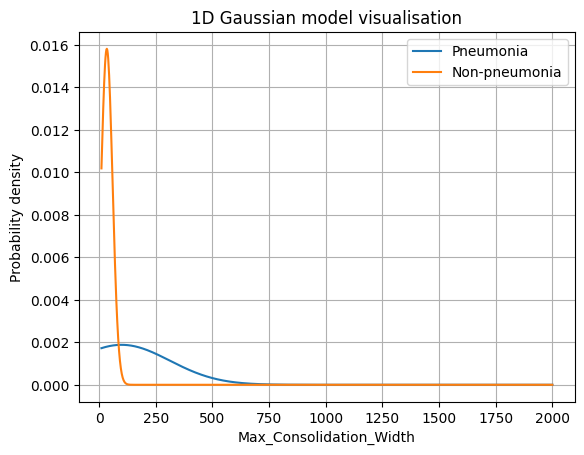

In [42]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Select one predictive feature
feature = 'Max_Consolidation_Width'

# Separates feature values by class
pneumonia_values = observations[observations[target_feature] == 'yes'][feature]
non_pneumonia_values = observations[observations[target_feature] == 'no'][feature]

# Calculates Gaussian parameters
pneumonia_mean = pneumonia_values.mean()
pneumonia_std = pneumonia_values.std()

non_pneumonia_mean = non_pneumonia_values.mean()
non_pneumonia_std = non_pneumonia_values.std()

# Creates x-axis values
x = np.linspace(observations[feature].min(), observations[feature].max(), 1000)

# Plots Gaussian distributions
plt.figure()

plt.plot(
    x,
    norm.pdf(x, pneumonia_mean, pneumonia_std),
    label='Pneumonia'
)

plt.plot(
    x,
    norm.pdf(x, non_pneumonia_mean, non_pneumonia_std),
    label='Non-pneumonia'
)

plt.xlabel(feature)
plt.ylabel('Probability density')

plt.title('1D Gaussian model visualisation')

plt.legend()
plt.grid(True)
plt.show()

>The visualisation shows that the feature distributions for pneumonia and non-pneumonia patients overlap, especially at lower feature values. This helps explain the weaker classification performance of the Naive Bayes model, as the model’s Gaussian assumptions may not fully capture the complexity of the dataset.

# 5. Decision Tree

In [43]:
# Import the packages we use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [44]:
# Load all the observations from file
observations = pd.read_csv('pneumonia_cleaned.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Shuffle all the observations
observations_shuffled = observations.sample(frac=1, random_state=99)

# Set the fraction of observations we will use for testing
testing_fraction = 0.4
split_index = int(observations_shuffled.shape[0] * testing_fraction)

# Split into testing observations and training observations ("horizontal split")
observations_test = observations_shuffled.iloc[:split_index]
observations_train = observations_shuffled.iloc[split_index:]

# Split into testing examples and testing labels ("vertical split")
test_examples = observations_test.drop(columns=['Patient_ID', target_feature]).to_numpy()
test_labels = observations_test[target_feature].to_numpy()

# Split into training examples and training labels ("vertical split")
train_examples = observations_train.drop(columns=['Patient_ID', target_feature]).to_numpy()
train_labels = observations_train[target_feature].to_numpy()

Decision tree model

In [45]:
# Create a DT classification model
model = DecisionTreeClassifier(random_state=99)

# Call the model's fitting/training algorithm, passing in our training examples and training labels
model.fit(train_examples, train_labels)

# Use the trained model to generate predictions based on our testing examples
predictions = model.predict(test_examples)

# Find the total number of model predictions that matched with their corresponding testing labels
correct_predictions = sum(predictions == test_labels)

# Calculate the model's accuracy: the fraction of predictions that were correct
accuracy = correct_predictions / len(test_labels)

# Display the accuracy as a single quantitative measure of overall performance
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

# Display the confusion matrix
print(confusion_matrix(test_labels, predictions))

# Display the classification report
print(classification_report(test_labels, predictions))

Accuracy: 0.6106194690265486 (or 61.1 %)
[[ 28  34]
 [ 54 110]]
              precision    recall  f1-score   support

          no       0.34      0.45      0.39        62
         yes       0.76      0.67      0.71       164

    accuracy                           0.61       226
   macro avg       0.55      0.56      0.55       226
weighted avg       0.65      0.61      0.63       226



>The model achieved an accuracy of 61.1%, performing better at identifying pneumonia cases than non-pneumonia cases. However, its relatively low recall for healthy patients suggests that the model may not be sufficiently reliable for clinical decision-making within the NHS case study.

Model Complexity

In [46]:
# Display the number of different labels/classes
print(model.n_classes_)

# Display the number of predictive features
print(model.n_features_in_)

2
10


>Model was trained using two output classes and all available predictive features from the dataset. This allowed the model to create rule-based splits using multiple clinical measurements when classifying pneumonia cases.

Tree visualisation

In [ ]:
# Grab a record of the predictive features
predictive_features = observations.drop(
    columns=['Patient_ID', target_feature]
).columns.to_numpy()

# Increase the default figure size so we can see the tree properly
plt.figure(figsize=(20, 10))

# Visualise the tree structure
plot_tree(
    model,
    feature_names=predictive_features,
    class_names=model.classes_,
    filled=True
)

plt.show()

>The visualisation shows how the model created a series of rule-based splits using different chest X-ray measurements to classify patients as pneumonia or non-pneumonia. While this structure makes the model more interpretable for NHS stakeholders, the large and complex tree also suggests a risk of overfitting, which may reduce reliability when applied to unseen patient data.

In [ ]:
# Create empty lists to store results
depths = []
accuracies = []

# Try different maximum tree depths
for depth in range(1, 21):

  # Create a decision tree classifier model object and set the maximum tree depth hyperparameter
  model = DecisionTreeClassifier(max_depth=depth, random_state=99)

  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the trained model to generate predictions based on our testing examples
  predictions = model.predict(test_examples)

  # Find the total number of model predictions that matched with their corresponding testing labels
  correct_predictions = sum(predictions == test_labels)

  # Calculate the model's accuracy
  accuracy = correct_predictions / len(test_labels)

  # Store the results
  depths.append(depth)
  accuracies.append(accuracy)

  # Display the results
  print("Depth:", depth, "Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

In [ ]:
# Show the relationship between tree depth and accuracy graphically
plt.figure()

plt.plot(depths, accuracies, marker='o')

plt.xlabel('Maximum tree depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree accuracy for different depths')

plt.grid(True)
plt.show()

>Increasing tree depth reduced model accuracy, suggesting that more complex trees may have overfitted the training data and performed less reliably on unseen patient cases.

In [ ]:
# Create empty lists to store results
minimum_parent_sizes = []
accuracies = []

# Try different minimum parent sizes
for minimum_parent_size in range(2, 51):

  # Create a decision tree classifier model object and set the minimum parent size hyperparameter
  model = DecisionTreeClassifier(
      random_state=99,
      min_samples_split=minimum_parent_size
  )

  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the trained model to generate predictions based on our testing examples
  predictions = model.predict(test_examples)

  # Find the total number of model predictions that matched with their corresponding testing labels
  correct_predictions = sum(predictions == test_labels)

  # Calculate the model's accuracy
  accuracy = correct_predictions / len(test_labels)

  # Store the results
  minimum_parent_sizes.append(minimum_parent_size)
  accuracies.append(accuracy)

  # Display the results
  print("Minimum parent size:", minimum_parent_size, "Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

In [ ]:
# Show the relationship between minimum parent size and accuracy graphically
plt.figure()

plt.plot(minimum_parent_sizes, accuracies, marker='o')

plt.xlabel('Minimum parent size')
plt.ylabel('Accuracy')
plt.title('Decision Tree accuracy for different minimum parent sizes')

plt.grid(True)
plt.show()

>The graph shows that increasing the minimum parent size improved tree accuracy, suggesting that restricting splits helped reduce overfitting and produced more reliable predictions for unseen patient data.

In [ ]:
# Creates a DT classification model using the selected minimum parent size
model = DecisionTreeClassifier(
    random_state=99,
    min_samples_split=10
)

# Call the model's fitting/training algorithm, passing in our training examples and training labels
model.fit(train_examples, train_labels)

# Use the trained model to generate predictions based on our testing examples
predictions = model.predict(test_examples)

# Find the total number of model predictions that matched with their corresponding testing labels
correct_predictions = sum(predictions == test_labels)

# Calculate the model's accuracy
accuracy = correct_predictions / len(test_labels)

# Display the accuracy
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

# Display the confusion matrix
print(confusion_matrix(test_labels, predictions))

# Display the classification report
print(classification_report(test_labels, predictions))

>The optimised model achieved an accuracy of 63.7%, showing a small improvement in balancing pneumonia and non-pneumonia predictions compared to the original model. However, performance for healthy patients remained relatively weak, suggesting that further optimisation would still be required before the model could reliably support NHS clinical decision-making.

The final Decision Tree used the selected hyperparameter value to balance accuracy and generalisation.

In [ ]:
# Increase the default figure size so we can see the tree properly
plt.figure(figsize=(20, 10))

# Visualise the tree structure
plot_tree(
    model,
    feature_names=predictive_features,
    class_names=model.classes_,
    filled=True
)

plt.title('Decision Tree model visualisation')
plt.show()

>The optimised Decision Tree visualisation shows a more structured and balanced set of rule-based splits compared to the original tree, suggesting that restricting model complexity helped reduce overfitting and improve the model’s ability to generalise to unseen patient data.

In [ ]:
# Get feature importances from the model
feature_importances = model.feature_importances_

# Sort the feature importances
sorted_indices = np.argsort(feature_importances)

# Plot feature importances
plt.figure()

plt.barh(
    predictive_features[sorted_indices],
    feature_importances[sorted_indices]
)

plt.xlabel('Feature importance')
plt.ylabel('Predictive feature')
plt.title('Decision Tree feature importance')

plt.grid(True)
plt.show()

>*Silhouette_Sign*, *Xray_Contrast*, and *Patient_Age* were the most influential features used by the Decision Tree model when predicting pneumonia cases.

1D

In [ ]:
# Select one predictive feature
feature_1 = 'Max_Consolidation_Width'

# Create a smaller dataset using only one feature
observations_1d = observations[[feature_1, target_feature]]

# Shuffle all the observations
observations_shuffled_1d = observations_1d.sample(frac=1, random_state=99)

# Split into testing observations and training observations ("horizontal split")
observations_test_1d = observations_shuffled_1d.iloc[:split_index]
observations_train_1d = observations_shuffled_1d.iloc[split_index:]

# Split into testing examples and testing labels ("vertical split")
test_examples_1d = observations_test_1d.drop(columns=target_feature).to_numpy()
test_labels_1d = observations_test_1d[target_feature].to_numpy()

# Split into training examples and training labels ("vertical split")
train_examples_1d = observations_train_1d.drop(columns=target_feature).to_numpy()
train_labels_1d = observations_train_1d[target_feature].to_numpy()

# Create a DT classification model
model_1d = DecisionTreeClassifier(random_state=99, min_samples_split=10)

# Call the model's fitting/training algorithm, passing in our training examples and training labels
model_1d.fit(train_examples_1d, train_labels_1d)

# Prepare our own grid of testing examples to use in visualization
grid_examples = np.linspace(
    train_examples_1d[:, 0].min() - 1,
    train_examples_1d[:, 0].max() + 1,
    500
).reshape(-1, 1)

# Make predictions for each of the examples in the grid
grid_predictions = model_1d.predict(grid_examples)

# Matplotlib wants integers for the colour codes in our scatter plot
unique_labels, grid_labels_int = np.unique(grid_predictions, return_inverse=True)
unique_labels, train_labels_int = np.unique(train_labels_1d, return_inverse=True)

# Visualise the final generalisation
plt.figure()

# Plot the generalisation
plt.scatter(grid_examples[:, 0], grid_labels_int, c=grid_labels_int, cmap='tab10')

# Plot the training data
plt.scatter(train_examples_1d[:, 0], train_labels_int, c=train_labels_int, edgecolors='black', cmap='tab10')

plt.xlabel(feature_1)
plt.ylabel('Class')
plt.title('1D Decision Tree generalisation visualisation')

plt.grid(True)
plt.show()

2D

In [ ]:
# Select two predictive features
feature_1 = 'Max_Consolidation_Width'
feature_2 = 'Silhouette_Sign'

# Create a smaller dataset using only two features
observations_2d = observations[[feature_1, feature_2, target_feature]]

# Shuffle all the observations
observations_shuffled_2d = observations_2d.sample(frac=1, random_state=99)

# Split into testing observations and training observations ("horizontal split")
observations_test_2d = observations_shuffled_2d.iloc[:split_index]
observations_train_2d = observations_shuffled_2d.iloc[split_index:]

# Split into testing examples and testing labels ("vertical split")
test_examples_2d = observations_test_2d.drop(columns=target_feature).to_numpy()
test_labels_2d = observations_test_2d[target_feature].to_numpy()

# Split into training examples and training labels ("vertical split")
train_examples_2d = observations_train_2d.drop(columns=target_feature).to_numpy()
train_labels_2d = observations_train_2d[target_feature].to_numpy()

# Create a DT classification model
model_2d = DecisionTreeClassifier(random_state=99, min_samples_split=10)

# Call the model's fitting/training algorithm, passing in our training examples and training labels
model_2d.fit(train_examples_2d, train_labels_2d)

# Prepare our own grid of testing examples to use in visualization
x_min = train_examples_2d[:, 0].min() - 1
x_max = train_examples_2d[:, 0].max() + 1
y_min = train_examples_2d[:, 1].min() - 1
y_max = train_examples_2d[:, 1].max() + 1

# Adjust this to get more/less definition in the grid
jump = 0.5

# Get help from numpy's meshgrid() function to be fast
grid_x, grid_y = np.meshgrid(
    np.arange(x_min, x_max, jump),
    np.arange(y_min, y_max, jump)
)

# Turn the results back into a deep table with only 2 columns
grid_examples = np.c_[grid_x.ravel(), grid_y.ravel()]

# Make predictions for each of the examples in the grid
grid_predictions = model_2d.predict(grid_examples)

# Matplotlib wants integers for the colour codes in our scatter plot
unique_labels, grid_labels_int = np.unique(grid_predictions, return_inverse=True)
unique_labels, train_labels_int = np.unique(train_labels_2d, return_inverse=True)

# Visualise the final generalisation
plt.figure()

# Plot the generalisation
plt.scatter(grid_examples[:, 0], grid_examples[:, 1], c=grid_labels_int, cmap='tab10')

# Plot the training data
plt.scatter(train_examples_2d[:, 0], train_examples_2d[:, 1], c=train_labels_int, edgecolors='black', cmap='tab10')

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title('2D Decision Tree generalisation visualisation')

plt.show()

In [ ]:
# Visualise training data in feature space
plt.figure()

# Matplotlib wants integers for the colour codes in our scatter plot
unique_labels, train_labels_int = np.unique(train_labels_2d, return_inverse=True)

# Plot the training data
plt.scatter(
    train_examples_2d[:, 0],
    train_examples_2d[:, 1],
    c=train_labels_int,
    edgecolors='black',
    cmap='tab10'
)

# Get the tree structure
tree = model_2d.tree_

# Plot the axis-parallel splits
for node in range(tree.node_count):

  # Get the feature used at this node
  feature_index = tree.feature[node]

  # Ignore leaf nodes
  if feature_index >= 0:

    # Get the threshold used at this node
    threshold = tree.threshold[node]

    # Plot vertical split line
    if feature_index == 0:
      plt.axvline(threshold, color='black', linestyle='--')

    # Plot horizontal split line
    if feature_index == 1:
      plt.axhline(threshold, color='black', linestyle='--')

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title('2D Decision Tree model parameter visualisation')

plt.grid(True)
plt.show()

3D

In [ ]:
# Import the packages we need
import plotly.graph_objects as go

# Select three predictive features
feature_1 = 'Max_Consolidation_Width'
feature_2 = 'Silhouette_Sign'
feature_3 = 'Cavity_Presence'

# Create a smaller dataset using only three features
observations_3d = observations[[feature_1, feature_2, feature_3, target_feature]]

# Convert labels into integers for plotting
unique_labels, labels_int = np.unique(observations_3d[target_feature], return_inverse=True)

# Create 3D scatter plot
fig = go.Figure(data=[
    go.Scatter3d(
        x=observations_3d[feature_1],
        y=observations_3d[feature_2],
        z=observations_3d[feature_3],
        mode='markers',
        marker=dict(
            size=4,
            color=labels_int,
            colorscale='Viridis'
        )
    )
])

# Add some axis labels
fig.update_layout(
    title='3D feature space visualisation',
    scene=dict(
        xaxis_title=feature_1,
        yaxis_title=feature_2,
        zaxis_title=feature_3
    )
)

fig.show()


# 5. Ensemble Classification

In [ ]:
# Import the packages i use
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# Load all the observations from file
observations = pd.read_csv('pneumonia_cleaned.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Shuffle all the observations
observations_shuffled = observations.sample(frac=1, random_state=99)

# Set the fraction of observations we will use for testing
testing_fraction = 0.4
split_index = int(observations_shuffled.shape[0] * testing_fraction)

# Split into testing observations and training observations
observations_test = observations_shuffled.iloc[:split_index]
observations_train = observations_shuffled.iloc[split_index:]

# Split into testing examples and labels
test_examples = observations_test.drop(columns=['Patient_ID', target_feature]).to_numpy()
test_labels = observations_test[target_feature].to_numpy()

# Split into training examples and labels
train_examples = observations_train.drop(columns=['Patient_ID', target_feature]).to_numpy()
train_labels = observations_train[target_feature].to_numpy()

# Standardise because k-NN is used in the voting ensemble
scaler = StandardScaler()
scaler.fit(train_examples)

train_examples = scaler.transform(train_examples)
test_examples = scaler.transform(test_examples)

Standardisation was applied because the voting ensemble includes k-NN, which is sensitive to feature scale.

Hard Voting Ensemble

In [ ]:
# Create the individual models
models = [
    ('knn', KNeighborsClassifier(n_neighbors=15)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=99))
]

# Create a hard voting ensemble
model = VotingClassifier(
    estimators=models,
    voting='hard'
)

# Train the ensemble
model.fit(train_examples, train_labels)

# Generate predictions
predictions = model.predict(test_examples)

# Calculate accuracy
correct_predictions = sum(predictions == test_labels)
accuracy = correct_predictions / len(test_labels)

# Display results
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

print(confusion_matrix(test_labels, predictions))
print(classification_report(test_labels, predictions))

> An accuracy of 65.5% was achieved and produced more balanced classification performance than several individual models, suggesting that combining multiple classifiers may improve robustness when diagnosing pneumonia cases


Soft Voting Ensemble

In [ ]:
# Create a soft voting ensemble
model = VotingClassifier(
    estimators=models,
    voting='soft'
)

# Train the ensemble
model.fit(train_examples, train_labels)

# Generate predictions
predictions = model.predict(test_examples)

# Calculate accuracy
correct_predictions = sum(predictions == test_labels)
accuracy = correct_predictions / len(test_labels)

# Display results
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

print(confusion_matrix(test_labels, predictions))
print(classification_report(test_labels, predictions))

# Display probabilities for the first five testing examples
print(model.predict_proba(test_examples[:5]))
print(model.classes_)

> The soft voting ensemble achieved an accuracy of 65.9%, slightly outperforming the hard voting ensemble. By combining probability estimates from multiple classifiers, the model produced more balanced predictions and provided confidence scores that could help NHS staff prioritise patients for further review.

Bagging Decision Trees

In [ ]:
# Creates a base Decision Tree model
base_model = DecisionTreeClassifier(random_state=99)

# Creates a bagging ensemble of Decision Trees
model = BaggingClassifier(
    estimator=base_model,
    n_estimators=100,
    random_state=99
)

# Trains the ensemble
model.fit(train_examples, train_labels)

# Generates predictions
predictions = model.predict(test_examples)

# Calculates accuracy
correct_predictions = sum(predictions == test_labels)
accuracy = correct_predictions / len(test_labels)

# Displays results
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

print(confusion_matrix(test_labels, predictions))
print(classification_report(test_labels, predictions))

> An accuracy of 71.2% was achieved, outperforming the voting ensembles and improving on the single Decision Tree model, suggesting that combining multiple Decision Trees reduced overfitting and produced more reliable predictions.

Random Forest

In [ ]:
# Createss a Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=99
)

# Trains the model
model.fit(train_examples, train_labels)

# Generates predictions
predictions = model.predict(test_examples)

# Calculates accuracy
correct_predictions = sum(predictions == test_labels)
accuracy = correct_predictions / len(test_labels)

# Displays results
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

print(confusion_matrix(test_labels, predictions))
print(classification_report(test_labels, predictions))

> An accuracy of 69.9% was achieved and strong recall for pneumonia-positive patients (0.82), outperforming the voting ensembles, although identifying non-pneumonia patients remained challenging across multiple models.

#6. Neural network MLP

In [ ]:
# Imports the packages we use
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Loads all the observations from file
observations = pd.read_csv('pneumonia_cleaned.csv')

# Sets the name of the target feature
target_feature = 'Pneumonia'

# Shuffles all the observations
observations_shuffled = observations.sample(frac=1, random_state=99)

# Sets the fraction of observations we will use for testing
testing_fraction = 0.4
split_index = int(observations_shuffled.shape[0] * testing_fraction)

# Splits into testing observations and training observations
observations_test = observations_shuffled.iloc[:split_index]
observations_train = observations_shuffled.iloc[split_index:]

# Splits into testing examples and labels
test_examples = observations_test.drop(columns=['Patient_ID', target_feature]).to_numpy()
test_labels = observations_test[target_feature].to_numpy()

# Splits into training examples and labels
train_examples = observations_train.drop(columns=['Patient_ID', target_feature]).to_numpy()
train_labels = observations_train[target_feature].to_numpy()

# Standardises the data
scaler = StandardScaler()
scaler.fit(train_examples)

train_examples = scaler.transform(train_examples)
test_examples = scaler.transform(test_examples)

Model

In [ ]:
# Creates a neural network classification model
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    random_state=99,
    max_iter=2000
)

# Trains the model
model.fit(train_examples, train_labels)

# Generates predictions
predictions = model.predict(test_examples)

# Calculates accuracy
correct_predictions = sum(predictions == test_labels)
accuracy = correct_predictions / len(test_labels)

# Displays results
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

print(confusion_matrix(test_labels, predictions))
print(classification_report(test_labels, predictions))

> The initial neural network model achieved an accuracy of 69.5% and strong recall for pneumonia-positive patients (0.84), suggesting it captured more complex patterns than simpler models, although the small dataset may limit generalisation to unseen patients.

Testing Hidden Layer Sizes

In [ ]:
# Create empty lists to store results
hidden_layer_sizes_list = []
accuracies = []

# Try different hidden layer sizes
hidden_layer_options = [(5,), (10,), (20,), (50,)]

for hidden_layer_size in hidden_layer_options:

  # Create a neural network classification model
  model = MLPClassifier(
      hidden_layer_sizes=hidden_layer_size,
      random_state=99,
      max_iter=2000
  )

  # Train the model
  model.fit(train_examples, train_labels)

  # Generate predictions
  predictions = model.predict(test_examples)

  # Calculate accuracy
  correct_predictions = sum(predictions == test_labels)
  accuracy = correct_predictions / len(test_labels)

  # Store the results
  hidden_layer_sizes_list.append(hidden_layer_size)
  accuracies.append(accuracy)

  # Display the accuracy
  print("Hidden layer size:", hidden_layer_size, "Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

>Different hidden layer sizes were tested to investigate whether increasing neural network complexity improved performance. The best accuracy was achieved with the smallest hidden layer size, (5,), at 69.9%. Accuracy decreased as the hidden layer became larger, suggesting that extra complexity did not improve generalisation on this pilot dataset and may have increased overfitting.

The warning means that the neural network optimiser did not fully converge within 2000 iterations, meaning the results should be interpreted cautiously and further investigation with a larger dataset may be required

Accuracy Plot

In [ ]:
import matplotlib.pyplot as plt

# Show the relationship between hidden layer size and accuracy
plt.figure()

plt.plot(
    [str(size) for size in hidden_layer_sizes_list],
    accuracies,
    marker='o'
)

plt.xlabel('Hidden layer size')
plt.ylabel('Accuracy')
plt.title('Neural network accuracy for different hidden layer sizes')

plt.grid(True)
plt.show()

The graph shows that smaller hidden layer sizes achieved better performance on the dataset. Accuracy gradually decreased as the neural network became more complex, suggesting that larger networks may have overfitted the training data rather than improving generalisation to unseen patients. For NHS stakeholders, this indicates that simpler neural network structures may currently be more appropriate for this pilot study dataset.

Final Neural Network Model

In [ ]:
# Create the final neural network model using the best hidden layer size
model = MLPClassifier(
    hidden_layer_sizes=(5,),
    random_state=99,
    max_iter=2000
)

# Train the model
model.fit(train_examples, train_labels)

# Generate predictions
predictions = model.predict(test_examples)

# Calculate accuracy
correct_predictions = sum(predictions == test_labels)
accuracy = correct_predictions / len(test_labels)

# Display results
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

print(confusion_matrix(test_labels, predictions))
print(classification_report(test_labels, predictions))

> An accuracy of 69.9% was achieved and strong recall for pneumonia-positive patients (0.88), suggesting it could be useful as a supportive screening tool, although performance for non-pneumonia patients remained weaker and further validation using a larger dataset would be required before clinical deployment.

# 7. Principal Component Analysis (PCA)

In [ ]:
# Import the packages we use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Load all the observations from file
observations = pd.read_csv('pneumonia_cleaned.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Shuffle all the observations
observations_shuffled = observations.sample(frac=1, random_state=99)

# Set the fraction of observations we will use for testing
testing_fraction = 0.4
split_index = int(observations_shuffled.shape[0] * testing_fraction)

# Split into testing observations and training observations
observations_test = observations_shuffled.iloc[:split_index]
observations_train = observations_shuffled.iloc[split_index:]

# Split into testing examples and labels
test_examples = observations_test.drop(columns=['Patient_ID', target_feature]).to_numpy()
test_labels = observations_test[target_feature].to_numpy()

# Split into training examples and labels
train_examples = observations_train.drop(columns=['Patient_ID', target_feature]).to_numpy()
train_labels = observations_train[target_feature].to_numpy()

# Standardise the predictive features
scaler = StandardScaler()

scaler.fit(train_examples)

train_examples = scaler.transform(train_examples)
test_examples = scaler.transform(test_examples)

Applying PCA

In [ ]:
# Create a PCA model reducing the dataset to two principal components
pca = PCA(n_components=2)

# Learn PCA transformation from training data only
pca.fit(train_examples)

# Apply PCA transformation to training and testing data
train_examples_pca = pca.transform(train_examples)
test_examples_pca = pca.transform(test_examples)

# Display transformed data shape
print(train_examples_pca.shape)
print(test_examples_pca.shape)

Explained Variance

In [ ]:
# Display explained variance ratios
print(pca.explained_variance_ratio_)

# Display total explained variance
print(sum(pca.explained_variance_ratio_))

PCA visualisation

In [ ]:
# Visualise the PCA-transformed training data
plt.figure()

# Converts labels into integer colour values
unique_labels, labels_int = np.unique(train_labels, return_inverse=True)

# Plots the transformed data
plt.scatter(
    train_examples_pca[:, 0],
    train_examples_pca[:, 1],
    c=labels_int,
    edgecolors='black',
    cmap='tab10'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('PCA visualisation of pneumonia dataset')

plt.grid(True)
plt.show()

KNN using PCA

In [ ]:
# Creates a k-NN classification model
model = KNeighborsClassifier(n_neighbors=15)

# Trains the model using PCA-transformed features
model.fit(train_examples_pca, train_labels)

# Generate predictions
predictions = model.predict(test_examples_pca)

# Calculate accuracy
correct_predictions = sum(predictions == test_labels)

accuracy = correct_predictions / len(test_labels)

# Display accuracy
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

# Display confusion matrix
print(confusion_matrix(test_labels, predictions))

# Display classification report
print(classification_report(test_labels, predictions))

>The model achieved an accuracy of 69.0%, showing that dimensionality reduction maintained strong predictive performance while simplifying the feature space, although overlap between classes continues to limit the model’s ability to accurately identify non-pneumonia patients.

# References

All code was reused from Collab notebooks from this module labs and what i have learnt in year 1+2, i integrated them into my assignment.

#Results

## Cross-Validation and ROC/AUC Comparison

In [ ]:
# Cross-Validation and ROC/AUC Comparison

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import make_scorer, f1_score, recall_score, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import pandas as pd
import matplotlib.pyplot as plt


# Uses my cleaned data
X = observations.drop(columns=["Patient_ID", "Pneumonia"]).to_numpy()
y = observations["Pneumonia"].to_numpy()


# Defines cross-validation folds
folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=99
)


# Positive class is pneumonia = yes
f1 = make_scorer(f1_score, pos_label="yes")
recall = make_scorer(recall_score, pos_label="yes")


# Models to compare
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDClassifier(loss="log_loss", random_state=99))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, probability=True, random_state=99))
    ]),

    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=15))
    ]),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        min_samples_split=10,
        random_state=99
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=99
    ),

    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(5,),
            max_iter=2000,
            random_state=99
        ))
    ])
}

In [ ]:
# Cross-validation comparison

results = []

for name, model in models.items():

    accuracy_scores = cross_val_score(
        model,
        X,
        y,
        cv=folds,
        scoring="accuracy"
    )

    recall_scores = cross_val_score(
        model,
        X,
        y,
        cv=folds,
        scoring=recall
    )

    f1_scores = cross_val_score(
        model,
        X,
        y,
        cv=folds,
        scoring=f1
    )

    results.append({
        "Model": name,
        "Mean Accuracy": accuracy_scores.mean(),
        "Accuracy SD": accuracy_scores.std(),
        "Mean Recall": recall_scores.mean(),
        "Recall SD": recall_scores.std(),
        "Mean F1": f1_scores.mean(),
        "F1 SD": f1_scores.std()
    })


cv_results = pd.DataFrame(results)
cv_results = cv_results.sort_values(by="Mean F1", ascending=False)

cv_results

>The cross-validation results demonstrate that several models maintained relatively stable performance across different folds of the dataset, suggesting reasonable generalisability despite the limited sample size.

>The SVM achieved the highest mean F1 score (0.827) and recall (0.985), indicating particularly strong performance in identifying pneumonia-positive patients. This is clinically important because false negatives may delay treatment and worsen patient outcomes.

>The relatively low standard deviation values across most models suggest that performance was reasonably consistent across different train/test partitions, increasing confidence that the findings are not solely dependent on one random split of the data.

>Naive Bayes performed worse than the other approaches, likely because the assumption of conditional independence between variables was not fully satisfied within the dataset.

In [ ]:
# ROC curve and AUC comparison

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=99
)

plt.figure(figsize=(8, 6))

auc_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    # Gets probability score for the positive class: "yes"
    if hasattr(model, "predict_proba"):
        yes_index = list(model.classes_).index("yes")
        y_scores = model.predict_proba(X_test)[:, yes_index]
    else:
        yes_index = list(model.named_steps["model"].classes_).index("yes")
        y_scores = model.predict_proba(X_test)[:, yes_index]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_scores,
        pos_label="yes"
    )

    auc_score = roc_auc_score(
        y_test,
        y_scores
    )

    auc_results.append({
        "Model": name,
        "AUC": auc_score
    })

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC = {auc_score:.2f}"
    )


plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


auc_results = pd.DataFrame(auc_results)
auc_results = auc_results.sort_values(by="AUC", ascending=False)

auc_results

>The ROC/AUC analysis produced slightly different rankings compared to the cross-validation F1 and recall scores. While kNN achieved the highest AUC score (0.725), SVM achieved substantially stronger recall and F1 performance.

>This suggests that although kNN provided slightly stronger overall class separation across probability thresholds, the SVM was more effective at consistently identifying pneumonia-positive patients at the selected decision threshold.

>In a clinical context, recall may be considered more important than maximising overall AUC because failing to detect pneumonia cases could have serious consequences for patient safety. Therefore, SVM may still represent the more clinically appropriate model despite its lower AUC score.

# Conclusions

Comparison table

In [ ]:
# Creates a summary table of model performance
import pandas as pd

model_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Polynomial Logistic Regression',
        'SVM',
        'k-NN',
        'Naive Bayes',
        'Decision Tree',
        'Hard Voting Ensemble',
        'Soft Voting Ensemble',
        'Bagging Ensemble',
        'Random Forest',
        'Neural Network',
        'PCA + k-NN'
    ],

    'Accuracy': [
        0.681,
        0.673,
        0.717,
        0.690,
        0.575,
        0.611,
        0.655,
        0.659,
        0.712,
        0.699,
        0.699,
        0.690
    ],

    'Recall (yes)': [
        0.79,
        0.79,
        0.96,
        0.84,
        0.44,
        0.67,
        0.68,
        0.68,
        0.82,
        0.82,
        0.88,
        0.70
    ],

    'F1-score (yes)': [
        0.77,
        0.76,
        0.83,
        0.80,
        0.60,
        0.71,
        0.74,
        0.74,
        0.81,
        0.80,
        0.81,
        0.74
    ]

})

# Sorts by accuracy
model_results = model_results.sort_values(
    by='Accuracy',
    ascending=False
)

# Rounds values
model_results = model_results.round(3)

# Displays the results
model_results

>Overall, this investigation suggests that the follow-on study should be funded. The results show that machine learning models can identify useful diagnostic patterns from simple numerical chest X-ray measurements, with several models achieving promising performance for detecting pneumonia-positive patients. The Support Vector Machine model was the strongest overall, achieving the highest accuracy (71.7%), recall for pneumonia cases (0.96), and F1-score (0.83). This is particularly important in the NHS context because missed pneumonia diagnoses could delay treatment and negatively affect patient outcomes.

>However, the models should not currently be used as a replacement for medically qualified staff. Several models still struggled to correctly identify non-pneumonia patients, which could lead to false positives and unnecessary follow-up checks. The pilot dataset was also relatively small and based only on simple measurements, meaning further validation is required before clinical deployment.

>Therefore, I recommend funding a larger follow-on study involving more patients, additional chest X-ray measurements, and wider clinical variables. The current results provide enough evidence that machine learning could support faster pneumonia screening and help NHS staff prioritise patients, but further development is needed before it could be safely used in real clinical decision-making.
